<h1>1.1 TSP</h1>

<h4>Wygeneruj chmurę n losowych punktów w 2D, a następnie zastosuj algorytm symulowanego
 wyżarzania do przybliżonego rozwiązania problemu komiwojażera dla tych punktów.</h4>
 

<h5> a) Przedstaw wizualizację otrzymanego rozwiązania dla 3 różnych wartości n oraz 3
różnych układów punktów w 2D (rozkład jednostajny, rozkład normalny z czterema
różnymi grupami parametrów, dziewięć odseparowanych grup punktów)</h5>

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

<h4>Generowanie</h4>

In [2]:
def generate_uniform_cities(num_cities):
    coords = np.random.uniform(low=0, high=100, size=(num_cities, 2))
    return [(x, y) for [x, y] in coords]


def generate_normal_4_groups(num_cities):
    centers = [(x, y) for x in [25, 75] for y in [25, 75]]
    
    scales = [4.0, 4.0, 4.0, 4.0] 
    
    cities = []
    
    base_count = num_cities // 4
    counts = [base_count] * 4
    counts[-1] += num_cities % 4 
    
    for i in range(4):
        group_coords = np.random.normal(loc=centers[i], scale=scales[i], size=(counts[i], 2))
        cities.extend([tuple(pt) for pt in group_coords])
        
    np.random.shuffle(cities)
    
    return cities


def generate_separated_9_groups(num_cities):
    centers = [(x, y) for x in [15, 50, 85] for y in [15, 50, 85]]
    
    scale = 2.5 
    
    cities = []
    
    base_count = num_cities // 9
    counts = [base_count] * 9
    counts[-1] += num_cities % 9 
    
    for i in range(9):
        group_coords = np.random.normal(loc=centers[i], scale=scale, size=(counts[i], 2))
        cities.extend([tuple(pt) for pt in group_coords])
        
    np.random.shuffle(cities)
    
    return cities

<h4>Wizualizacja</h4>

In [3]:
import matplotlib.pyplot as plt

def visualize_tsp(cities, route=None):
    
    x_coords = [city[0] for city in cities]
    y_coords = [city[1] for city in cities]

    plt.figure(figsize=(7, 7))
    

    plt.scatter(x_coords, y_coords, color='red', s=50, zorder=5, label='Cities')

    if route is not None:
        num_cities = len(route)
        
        # Prepare individual line segments: (city[route[i]], city[route[i+1]])
        segments = []
        for i in range(num_cities-1):
            start_city = cities[route[i]]
            # Wrap around to the first city to close the loop smoothly
            end_city = cities[route[i + 1]]
            segments.append((start_city, end_city))

        # 3. Create values 0.0 to 1.0 based on segment sequence position
        num_segments = len(segments)
        # Sequence progress from start (0.0) to end (1.0)
        # For gradient, map progress 0.0 to 1.0 along the *sequence* of links
        # Note: num_segments is n, and n-1 links, so progress for each link is i/(n-1)
        # Correction: range(num_segments) is 0...n-1, mapping to 0..1 for n colors/segments
        color_indices = np.linspace(0, 1, num_segments)        
        # Select a continuous color map (conceptually gradient) for distinct functional colors
        cmap = plt.get_cmap('cool') # Can be any sequential colormap conceptually
        
        # Apply the sequential gradient colors to the segments conceptually
        lc = LineCollection(segments, cmap=cmap, linewidth=2.0, zorder=4, alpha=0.9, label='Gradient Path')
        # Set the colors based on mapped values sequentially
        lc.set_array(np.array(color_indices)) # Values for colormap mapping
        
        # Add the line collection to the axes
        plt.gca().add_collection(lc)
        
        # Optional: Add a colorbar conceptually below to show path sequence direction/progress
        # The colorbar would show distinct colors from colormap, conceptually mapping start to end
        # This part requires linking colorbar and colormap/LineCollection appropriately in real matplotlib

    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()


In [4]:
import matplotlib.pyplot as plt

def visualize_best_energy_and_temp(best_energies, temperatures):
    """
    Visualizes the best energy found so far and the temperature decay 
    over the number of iterations using a dual-axis chart.
    """
    # The X-axis is simply the iteration number (0 to N)
    iterations = range(len(best_energies))

    # Set up the main figure and the first axis (Left side)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- LEFT Y-AXIS: Best Energy ---
    ax1.set_xlabel('Number of Iterations', fontsize=12)
    ax1.set_ylabel('Best Energy (Total Distance)', color='red', fontsize=12)
    
    # Plot the Best Energy as a smooth, downward stair-step line
    ax1.plot(iterations, best_energies, color='red', label='Best Energy', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- RIGHT Y-AXIS: Temperature ---
    # Create a secondary Y-axis that shares the same X-axis
    ax2 = ax1.twinx()  
    ax2.set_ylabel('Current Temperature', color='orange', fontsize=12)
    
    # Plot the Temperature as a decaying curve
    ax2.plot(iterations, temperatures, color='orange', label='Temperature', linestyle='--', linewidth=2.5)
    ax2.tick_params(axis='y', labelcolor='orange')

    # Combine the legends from both axes into one neat box
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=11)

    # Add title and display the plot
    plt.tight_layout()
    plt.show()



In [5]:
#wyliczamy odległość
def distance(city1, city2):
    return math.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

In [6]:
#wyliczamy cała drogę 
def total_path_distance(route, cities):
    total_dist = 0.0
    num_cities = len(route)
    for i in range(num_cities):
        current_city = cities[route[i]]

        next_city = cities[route[(i + 1) % num_cities]]
        total_dist += distance(current_city, next_city)
    return total_dist

<h4>Swaps</h4>

In [7]:
def apply_arbitary_swap(route):
    neighbour = route.copy()

    i, j = random.sample(range(len(route)), 2)

    neighbour[i], neighbour[j] = neighbour[j], neighbour[i]
    return neighbour


def apply_cosecutive_swap(route):
# Create a copy of the route
    neighbour = route.copy()
    
    i = random.randint(0, len(neighbour)-1)    
    j = (i+1) % len(neighbour)

    neighbour[i], neighbour[j] = neighbour[j], neighbour[i]

    
    return neighbour

def apply_reversed_swap(route):
# Create a copy of the route
    neighbour = route.copy()
    
    # Pick two random distinct indices
    i, j = random.sample(range(len(route)), 2)
    
    # Ensure i is the smaller index
    if i > j:
        i, j = j, i
        
    # Reverse the sub-list between i and j
    neighbour[i:j+1] = reversed(neighbour[i:j+1])
    
    return neighbour

<h4>Temperatures</h4>

In [8]:
def temp_exp(par, itr, temp = 1500.0 ): return temp * (par ** itr)

def temp_log(par, itr, temp = 100.0 ): return temp / math.log(2+itr)

def temp_diff(par,itr, temp = 1.0 ): return max(0,temp - (par ** itr))

<h4>Algorythm</h4>

341.93268002267075


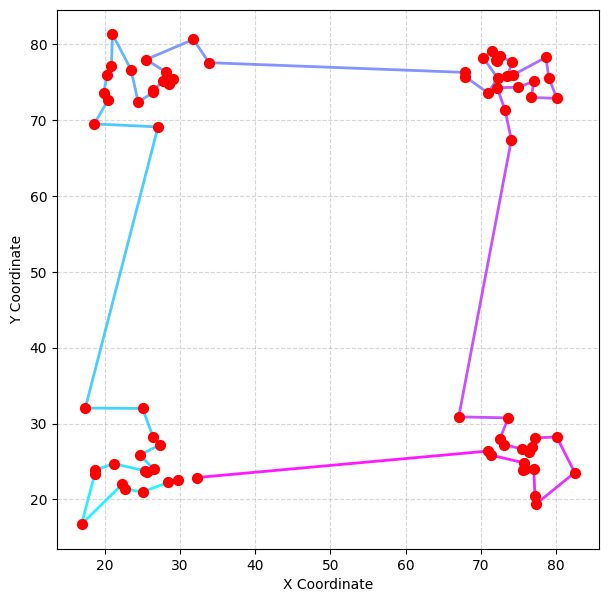

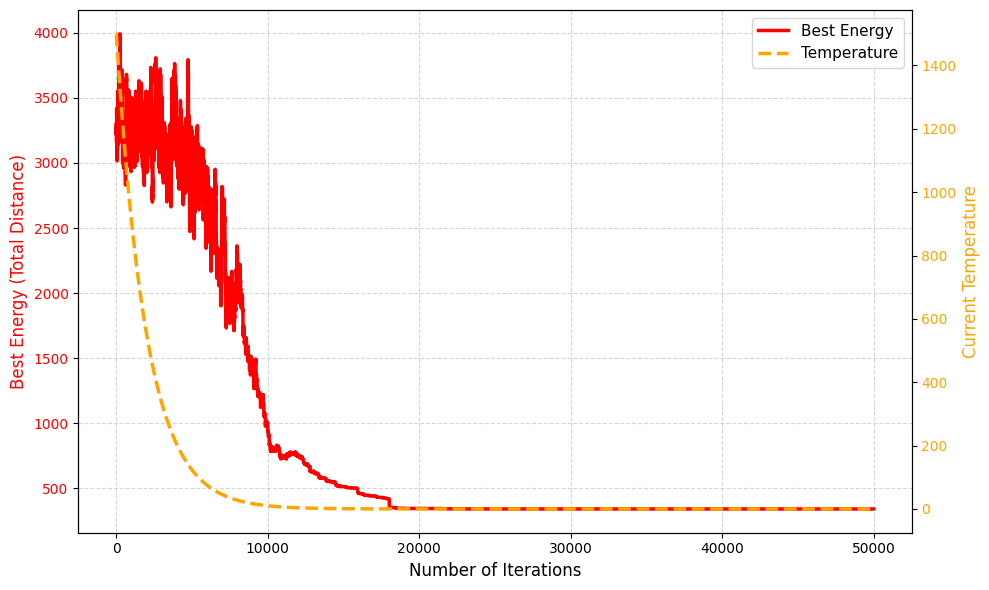

In [9]:
def simulated_annealing_tsp(cities, temp, max_iterations, cooling):
    n = len(cities)
    route_history = []
    
    current_route = list(range(n))
    current_distance = total_path_distance(current_route, cities)
    
    best_route = current_route.copy()
    best_distance = current_distance
    

    distancies = [best_distance]
    temperatures = [1500.0]
    for iteration in range(max_iterations):
        
        current_temp = temp(cooling, iteration)
        
            
        new_route = apply_reversed_swap(current_route)
        new_distance = total_path_distance(new_route, cities)
        
        distance_diff = new_distance - current_distance
        
        if distance_diff < 0:
            current_route = new_route
            current_distance = new_distance

        elif random.random() < math.exp(-distance_diff / max(current_temp, 1e-10)):
            current_route = new_route
            current_distance = new_distance
                
        if current_distance < best_distance:                
            best_route = current_route.copy()
            best_distance = current_distance
        
        if iteration % 50 == 0 or iteration == max_iterations - 1:
            route_history.append(best_route.copy())
        distancies.append(current_distance)
        temperatures.append(current_temp)

            
    return best_route, best_distance, distancies, temperatures, route_history




cities = generate_normal_4_groups(75)
route, best_distance, distancies, temperaturess, route_history = simulated_annealing_tsp(cities, temp_exp, 50000, 0.9995)
print(best_distance)
visualize_tsp(cities, route=route)
visualize_best_energy_and_temp(distancies, temperaturess)

Generating gradient GIF, please wait...


KeyboardInterrupt: 

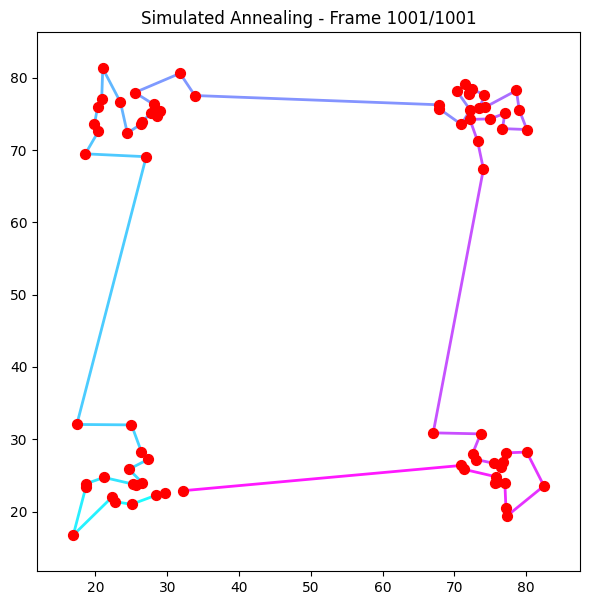

In [10]:
import matplotlib.animation as animation

def create_tsp_gradient_gif(cities, route_history, filename="tsp_optimization.gif"):
    fig, ax = plt.subplots(figsize=(7, 7))
    
    x_coords = [city[0] for city in cities]
    y_coords = [city[1] for city in cities]
    
    # Plot the cities
    ax.scatter(x_coords, y_coords, color='red', s=50, zorder=5)
    
    ax.set_xlim(min(x_coords) - 5, max(x_coords) + 5)
    ax.set_ylim(min(y_coords) - 5, max(y_coords) + 5)
    
    # Initialize an empty LineCollection with the 'cool' colormap
    lc = LineCollection([], cmap='cool', linewidth=2.0, zorder=4, alpha=0.9)
    ax.add_collection(lc)
    
    def update(frame):
        route = route_history[frame]
        segments = []
        
        # Create segments without closing the loop
        for i in range(len(route) - 1):
            segments.append((cities[route[i]], cities[route[i + 1]]))
            
        # Update the line segments and their corresponding color values
        lc.set_segments(segments)
        lc.set_array(np.linspace(0, 1, len(segments)))
        
        ax.set_title(f"Simulated Annealing - Frame {frame+1}/{len(route_history)}")
        return lc,

    print("Generating gradient GIF, please wait...")
    ani = animation.FuncAnimation(
        fig, update, frames=len(route_history), blit=True, interval=100
    )
    
    ani.save(filename, writer='pillow')
    print(f"GIF saved successfully as {filename}")
    plt.close()
create_tsp_gradient_gif(cities, route_history)